# Stratified performance — latent-cluster axis (v1)

The elevation / Δ-elevation / density / latitude axes (in `stratified_performance.ipynb`)
showed weak and inconsistent patterns — TESSERA's lift doesn't sort by simple
physical metadata. This notebook tests the alternative: **let the TESSERA latents
themselves define the strata**.

## Method

1. Fit k-means (k=8) on the **frozen 16-d VAE bottleneck latents** for every
   TESSERA-covered station globally. This is the canonical, downstream-task-
   agnostic TESSERA representation — picking the 8-d *projected* latents
   instead would give different clusters for every trained model, since the
   projection is jointly learned with the downscaling task.
2. Assign cluster IDs to all evaluated test stations across the five
   `snapshot_14y_*` regions.
3. Per-cluster: geographic centroid + scatter map, mean elev / Δ-elev /
   density, top-N example stations. Plus a 2D PCA projection of the 16-d
   latent space coloured by cluster, so you can see whether the clusters
   are separable in the dominant variance directions.
4. **Stratification:** the standard MAE-and-gap layout used in the previous
   stratified notebook, but with cluster ID on the x-axis.
5. **k-sweep sanity check** at k ∈ {4, 6, 8, 12, 16} — is the headline
   "some clusters benefit more than others" stable across k?

## What this is and isn't

This is **v1**: latent-space clustering. The clusters are interpretable only
through their per-cluster characterisation (location, terrain, station
density). Hand-labelling them ("forest", "coastal", "urban") needs either
an external land-cover map (CORINE / ESA WorldCover) or a TESSERA-trained
land-cover classifier — Pedro is following up with the group on whether one
already exists.

**v2** (separate notebook, later): cluster the raw 64×64 patch embeddings
directly and compare the cluster structure against this latent-based one.
That's the TESSERA-fidelity check — does the VAE preserve the
discriminative structure of the raw patches?


In [15]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.cluster.vq import kmeans2
from scipy.spatial import cKDTree

sys.path.insert(0, str(Path.cwd()))
import _helpers
import importlib
importlib.reload(_helpers)
from _helpers import (
    RunCategory,
    _top_n_experiments,
    _augment_df_with_classification,
    output_dir_for_folder,
)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.constrained_layout.use': True,
})


In [16]:
# Same five folders + winner-selection rules as the sibling notebook.
FOLDERS = [
    'snapshot_14y_eu',
    'snapshot_14y_us',
    'snapshot_14y_east_asia',
    'snapshot_14y_australia',
    'snapshot_14y_southern_africa',
]
SEEDS = [42, 123, 456]
VARIABLES = ['t2m', 'wind']
DIST_PREF = {'t2m': ['gaussian'], 'wind': ['truncated_normal', 'gaussian']}

# Dataset (for stations.csv → station_id ↔ region, lat, lon, elev mapping).
DATASET_DIR = Path('../.tmp_output/dataset_timestamp_global')

# Frozen 16-d VAE latents — the canonical TESSERA representation. Matches
# the path pick_probe_set.py / submit.sh use.
VAE_LATENTS_PATH = Path('../.tmp_output/processed/station_latents_lat16_grad0.5.npy')
VAE_LATENTS_CSV  = Path('../.tmp_output/processed/tessera_global/station_list_filtered.csv')

# Headline cluster count + k-sweep grid for sanity check.
K_HEADLINE = 8
K_SWEEP    = [4, 6, 8, 12, 16]

# k-means seed (reproducible cluster labels run-to-run).
KMEANS_SEED = 42

# k-NN parameter for the density feature (reused from the sibling notebook).
K_NEAREST = 5


In [17]:
# Mirrors cells 3–5 of stratified_performance.ipynb. Self-contained so this
# notebook runs without the other one being open.
df_all = _helpers.load_all_results(FOLDERS, seeds=SEEDS)
df_all = _augment_df_with_classification(df_all)
print(f'Loaded {len(df_all)} run records.')


# NOTE — workaround for _helpers._top_n_experiments bug:
#   That function builds its filter column as ``f"{variable}_{_point_estimate_mae_column(dist)}"``
#   and relies on column presence to discriminate distributions. The
#   gaussian→"mae" / truncated_normal→"rmse" map at line 1037 of _helpers.py
#   means that for distribution="truncated_normal" the function ends up
#   filtering on ``wind_rmse``, which is non-NaN for EVERY wind run regardless
#   of head — so a folder with only gaussian wind runs gets reported as having
#   a truncated_normal winner.
# We work around it here by pre-filtering on the per-row ``{var}_distribution``
# column (added by _helpers._load_run_record at line 424). With that filter
# applied, _top_n_experiments still works correctly within the
# distribution-specific subset, and folders without TN runs skip the TN branch
# of the DIST_PREF chain cleanly.
def pick_winner_pair(df_sub: pd.DataFrame, variable: str) -> dict | None:
    dist_col = f'{variable}_distribution'

    def in_dist(df, dist):
        if dist_col not in df.columns:
            return df.iloc[0:0]
        return df[df[dist_col] == dist]

    chosen_dist = None
    tessera_name = None
    for dist in DIST_PREF[variable]:
        candidates = in_dist(df_sub, dist)
        if candidates.empty:
            continue
        top = _top_n_experiments(
            candidates, variable, dist,
            RunCategory.TESSERA_VANILLA, 'single', top_n=1, encoder='vae',
        )
        if top:
            chosen_dist = dist
            tessera_name = top[0]
            break
    if not tessera_name:
        return None

    baseline_name = None
    baseline_dist = None
    search = [chosen_dist] + [d for d in DIST_PREF[variable] if d != chosen_dist]
    for dist in search:
        candidates = in_dist(df_sub, dist)
        if candidates.empty:
            continue
        top = _top_n_experiments(
            candidates, variable, dist,
            RunCategory.TRAINED_NO_TESSERA, 'single', top_n=1,
        )
        if top:
            baseline_dist = dist
            baseline_name = top[0]
            break
    if not baseline_name:
        return None
    return {
        'variable': variable,
        'tessera_distribution': chosen_dist, 'tessera_experiment': tessera_name,
        'baseline_distribution': baseline_dist, 'baseline_experiment': baseline_name,
    }


winners = []
for folder in FOLDERS:
    sub = df_all[df_all['source_folder'] == folder]
    if sub.empty:
        continue
    for variable in VARIABLES:
        pair = pick_winner_pair(sub, variable)
        if pair is None:
            print(f'[{folder}/{variable}] no usable pair; skipping.')
            continue
        pair['folder'] = folder
        winners.append(pair)
winners_df = pd.DataFrame(winners)[
    ['folder', 'variable', 'tessera_distribution', 'tessera_experiment',
     'baseline_distribution', 'baseline_experiment']
]
print()
print('=== Winners ===')
with pd.option_context('display.max_colwidth', None, 'display.width', 200):
    print(winners_df.to_string(index=False))


Loaded 2607 run records.

=== Winners ===
                      folder variable tessera_distribution                                                  tessera_experiment baseline_distribution            baseline_experiment
             snapshot_14y_eu      t2m             gaussian     t2m_snap_vae_lat16_proj8_bilinear_concat_with_elev_no_static_wd              gaussian   t2m_snap_setconv_baseline_wd
             snapshot_14y_eu     wind     truncated_normal wind_truncnormal_snap_vae_lat16_proj8_concat_with_elev_no_static_wd              gaussian  wind_snap_setconv_baseline_wd
             snapshot_14y_us      t2m             gaussian          t2m_snap_vae_lat16_proj8_mlp_concat_with_elev_no_static_wd              gaussian  t2m_snap_bilinear_baseline_wd
             snapshot_14y_us     wind             gaussian           wind_snap_vae_lat16_proj8_mlp_film_with_elev_no_static_wd              gaussian wind_snap_bilinear_baseline_wd
      snapshot_14y_east_asia      t2m             gaussian

In [18]:
# Mirrors cell 5/6 of the sibling: load per-station NPZ + seed-aggregate.
def load_station_records(folder, experiment, role, variable, seeds=SEEDS):
    out = []
    for seed in seeds:
        npz = output_dir_for_folder(folder) / f'{experiment}_seed{seed}' / 'test_station_errors.npz'
        if not npz.exists():
            continue
        try:
            d = dict(np.load(npz, allow_pickle=True))
        except Exception as e:
            print(f'  failed to load {npz}: {e}')
            continue
        mae_k = f'{variable}_station_mae'
        cnt_k = f'{variable}_station_count'
        if mae_k not in d or cnt_k not in d:
            continue
        n = len(d['station_ids'])
        counts = d[cnt_k]
        for i in range(n):
            if counts[i] == 0:
                continue
            out.append({
                'folder': folder, 'variable': variable, 'role': role,
                'experiment': experiment, 'seed': seed,
                'station_id': str(d['station_ids'][i]),
                'lat': float(d['station_lats'][i]),
                'lon': float(d['station_lons'][i]),
                'elev': float(d['station_elevs'][i]),
                'delta_elev': float(d['station_delta_elevs'][i]),
                'mae': float(d[mae_k][i]),
                'count': int(counts[i]),
            })
    return out


records = []
for w in winners:
    records.extend(load_station_records(w['folder'], w['tessera_experiment'], 'tessera', w['variable']))
    records.extend(load_station_records(w['folder'], w['baseline_experiment'], 'baseline', w['variable']))
raw = pd.DataFrame.from_records(records)

station_agg = (
    raw.groupby(['folder', 'variable', 'role', 'station_id'], as_index=False)
       .agg(
           lat=('lat', 'first'),
           lon=('lon', 'first'),
           elev=('elev', 'first'),
           delta_elev=('delta_elev', 'first'),
           mae=('mae', 'mean'),
           mae_std=('mae', 'std'),
           n_seeds=('mae', 'count'),
       ))
station_agg['abs_delta_elev'] = station_agg['delta_elev'].abs()
print(f'station_agg: {len(station_agg):,} rows '
      f'(unique stations across folders/variables/roles).')


station_agg: 4,906 rows (unique stations across folders/variables/roles).


In [19]:
# Load the 16-d VAE latents and the row-aligned station CSV. Filter to rows
# with non-NaN latent (= TESSERA-valid stations). The result is a DataFrame:
# (station_id, lat0..lat15) for every TESSERA-valid station globally.
if not VAE_LATENTS_PATH.exists():
    raise FileNotFoundError(
        f'VAE latents not found at {VAE_LATENTS_PATH}. Adjust the path in '
        f'the config cell.'
    )
if not VAE_LATENTS_CSV.exists():
    raise FileNotFoundError(
        f'VAE latents CSV not found at {VAE_LATENTS_CSV}.'
    )

# mmap so loading the whole NPY doesn't cost RAM.
latents_all = np.load(str(VAE_LATENTS_PATH), mmap_mode='r')
csv = pd.read_csv(VAE_LATENTS_CSV)
csv['station_id'] = csv['station_id'].astype(str)
if len(csv) != latents_all.shape[0]:
    raise RuntimeError(
        f'Row-mismatch: CSV has {len(csv)} rows, latents has {latents_all.shape[0]}. '
        f'These files must be row-aligned.'
    )
print(f'Loaded {latents_all.shape[0]:,} latent rows × {latents_all.shape[1]} dims '
      f'(latent dimensionality).')

# Filter to non-NaN.
valid_mask = ~np.isnan(latents_all).any(axis=1)
valid_latents = np.array(latents_all[valid_mask], dtype=np.float64)
valid_csv = csv.loc[valid_mask, ['station_id']].reset_index(drop=True)
print(f'TESSERA-valid (non-NaN-latent) stations globally: {len(valid_csv):,}')


Loaded 38,870 latent rows × 16 dims (latent dimensionality).
TESSERA-valid (non-NaN-latent) stations globally: 35,390


In [20]:
# Standardise per-dim (k-means is scale-sensitive; without this, dims with
# larger natural variance would dominate the distance metric).
mu     = valid_latents.mean(axis=0, keepdims=True)
sigma  = valid_latents.std(axis=0, keepdims=True) + 1e-12
latents_std = (valid_latents - mu) / sigma

# Fit headline k-means. scipy's kmeans2 with minit='++' = k-means++ init.
np.random.seed(KMEANS_SEED)
centroids, labels = kmeans2(
    latents_std, k=K_HEADLINE, seed=KMEANS_SEED, minit='++',
    iter=200, missing='raise',
)
print(f'Fitted k-means (k={K_HEADLINE}) on {len(latents_std):,} standardised latents.')

# Cluster sizes (sanity: no degenerate clusters with 0 or single-digit members).
cluster_sizes = pd.Series(labels).value_counts().sort_index()
print(f'\nCluster sizes:')
print(cluster_sizes.to_string())

# Store cluster label per station_id for downstream merge.
cluster_lookup = (
    pd.DataFrame({'station_id': valid_csv['station_id'].values,
                  'cluster': labels})
)
print(f'\ncluster_lookup: {len(cluster_lookup):,} (station_id, cluster) pairs.')


Fitted k-means (k=8) on 35,390 standardised latents.

Cluster sizes:
0    4739
1    2432
2    2618
3    8778
4    3498
5    5228
6    5322
7    2775

cluster_lookup: 35,390 (station_id, cluster) pairs.


In [21]:
# Join cluster labels into station_agg. Some test stations may not have a
# latent (extremely rare given the runs use TESSERA filtering at train time,
# but defensive nevertheless).
before = len(station_agg)
station_agg = station_agg.merge(cluster_lookup, on='station_id', how='left')
missing = station_agg['cluster'].isna().sum()
station_agg['cluster'] = station_agg['cluster'].astype('Int64')
print(f'Merged. {missing} of {before} rows have no cluster label '
      f'(no matching latent — should be 0 or near-0).')
print()
print('Per-cluster counts (across folders / variables / roles):')
print(station_agg.groupby('cluster').size().to_string())


Merged. 0 of 4906 rows have no cluster label (no matching latent — should be 0 or near-0).

Per-cluster counts (across folders / variables / roles):
cluster
0     239
1     376
2     352
3    1981
4     568
5    1000
6     362
7      28


In [22]:
# Per-cluster characterisation. The view we want is per-cluster ×
# (centroid, geographic spread, terrain stats, region mix) so each cluster
# can be informally labelled before we look at the MAE plots.
# We use the seed-aggregated row of station_agg restricted to role='tessera'
# (avoids duplication; lat/lon/elev are role-invariant).
char_basis = station_agg[station_agg['role'] == 'tessera'].copy()

per_cluster_rows = []
for cluster_id, g in char_basis.groupby('cluster'):
    if pd.isna(cluster_id):
        continue
    region_counts = g['folder'].str.replace('snapshot_14y_', '', regex=False).value_counts()
    region_str = ', '.join(f'{r}:{n}' for r, n in region_counts.items())
    per_cluster_rows.append({
        'cluster':      int(cluster_id),
        'n_stations':   len(g),
        'lat_mean':     g['lat'].mean(),
        'lat_std':      g['lat'].std(),
        'lon_mean':     g['lon'].mean(),
        'lon_std':      g['lon'].std(),
        'elev_mean':    g['elev'].mean(),
        'elev_std':     g['elev'].std(),
        'abs_delta_elev_mean': g['abs_delta_elev'].mean(),
        'regions':      region_str,
    })
cluster_chars = pd.DataFrame(per_cluster_rows).sort_values('cluster')
with pd.option_context('display.float_format', '{:.2f}'.format,
                       'display.width', 200, 'display.max_colwidth', 80):
    print(cluster_chars.to_string(index=False))


 cluster  n_stations  lat_mean  lat_std  lon_mean  lon_std  elev_mean  elev_std  abs_delta_elev_mean                                       regions
       0         120     -4.46    30.45     22.51    31.86     764.14    474.68                88.41  southern_africa:76, eu:37, australia:4, us:3
       1         188     45.12     5.74      9.62    25.41    1459.83    601.18               433.02                     eu:178, east_asia:8, us:2
       2         188     39.45     6.36   -109.26     8.21     862.05    692.61               124.39                                        us:188
       3         990     47.88     5.56      9.44    11.06     239.17    219.85               110.81                                  eu:989, us:1
       4         284     56.55    14.84     -4.46    44.49     203.17    246.01               137.13 eu:235, us:41, east_asia:4, southern_africa:4
       5         501     37.71     5.90    -86.07    10.95     185.70    163.73                31.53                  

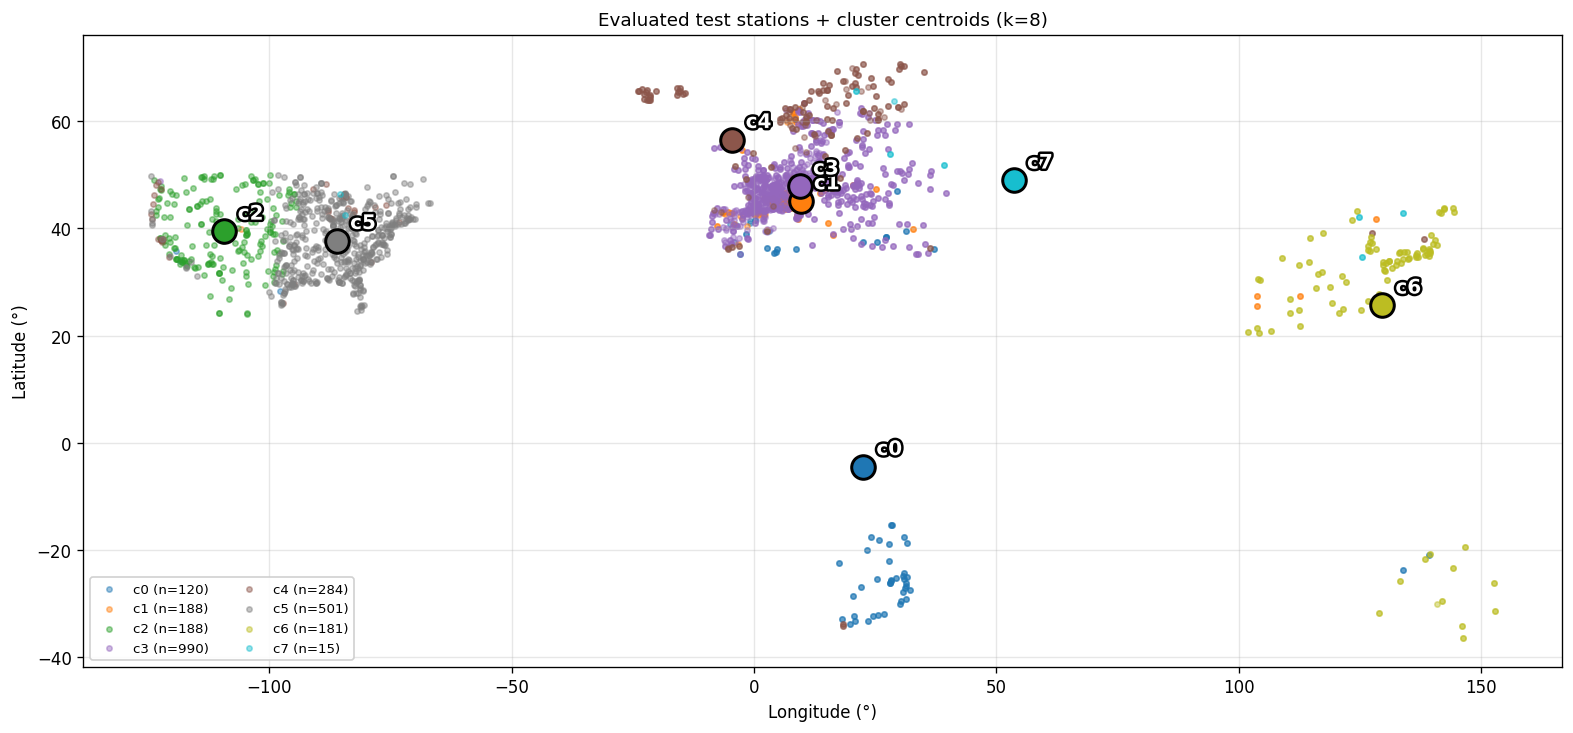

In [23]:
# Geographic scatter of every evaluated test station, coloured by cluster.
# Cluster centroids (geographic mean of each cluster's stations) overlaid as
# large markers + labels — the at-a-glance reference for where each cluster id
# sits geographically.
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(13, 6))
char_basis_local = char_basis.dropna(subset=['cluster']).copy()
cmap = plt.get_cmap('tab10', K_HEADLINE)
for cluster_id, g in char_basis_local.groupby('cluster'):
    cid = int(cluster_id)
    ax.scatter(g['lon'], g['lat'], s=10, alpha=0.45,
               color=cmap(cid), label=f'c{cid} (n={len(g)})')

# Centroid markers + labels.
for _, row in cluster_chars.iterrows():
    cid = int(row['cluster'])
    ax.scatter(
        row['lon_mean'], row['lat_mean'],
        s=200, color=cmap(cid),
        edgecolor='black', linewidth=1.8, zorder=5,
    )
    ax.annotate(
        f'c{cid}', (row['lon_mean'], row['lat_mean']),
        xytext=(8, 7), textcoords='offset points',
        fontsize=12, fontweight='bold', color='white', zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground='black')],
    )
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Evaluated test stations + cluster centroids (k={K_HEADLINE})')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=8, ncol=2, framealpha=0.9)
plt.show()


In [24]:
# Top-N most-representative stations per cluster, defined as the stations whose
# 16-d standardised latent is closest to the cluster's centroid in latent space
# (NOT geographic centre — these are the stations that look most like "the
# typical cluster member" in TESSERA's eyes, which is what you want when
# hand-labelling).
# Drop the output table into OSM / Google Maps / a CORINE viewer to put a
# semantic name on each cluster (forest / urban / coastal / cropland / etc.).
N_EXAMPLES = 5

sid_to_idx = dict(zip(valid_csv['station_id'].values, range(len(valid_csv))))

example_rows = []
for cluster_id in sorted(char_basis_local['cluster'].dropna().unique()):
    cid = int(cluster_id)
    g = char_basis_local[char_basis_local['cluster'] == cid].copy()
    centroid_vec = centroids[cid]
    dists = []
    for sid in g['station_id'].values:
        idx = sid_to_idx.get(sid)
        if idx is None:
            dists.append(np.inf)
            continue
        dists.append(float(np.linalg.norm(latents_std[idx] - centroid_vec)))
    g['dist_to_centroid'] = dists
    top = g.nsmallest(N_EXAMPLES, 'dist_to_centroid')
    for _, row in top.iterrows():
        example_rows.append({
            'cluster':           cid,
            'station_id':        row['station_id'],
            'folder':            row['folder'].replace('snapshot_14y_', ''),
            'lat':               row['lat'],
            'lon':               row['lon'],
            'elev_m':            row['elev'],
            'abs_delta_elev_m':  row['abs_delta_elev'],
            'dist_to_centroid':  row['dist_to_centroid'],
        })
examples = pd.DataFrame(example_rows)

print(f'Top-{N_EXAMPLES} most-representative stations per cluster '
      f'(closest in standardised latent space).')
print('Copy lat/lon into OSM / Google Maps / land-cover viewers for hand-labelling.')
print()
with pd.option_context('display.float_format', '{:.3f}'.format,
                       'display.width', 200,
                       'display.max_colwidth', 30):
    # Insert blank-line separators between clusters so the table is easy to scan.
    for cid, g in examples.groupby('cluster'):
        print(g.to_string(index=False, header=(cid == examples['cluster'].iloc[0])))
        print()


Top-5 most-representative stations per cluster (closest in standardised latent space).
Copy lat/lon into OSM / Google Maps / land-cover viewers for hand-labelling.

 cluster  station_id          folder     lat    lon  elev_m  abs_delta_elev_m  dist_to_centroid
       0 WZI0000FDOT southern_africa -26.704 31.426 341.000           275.053             2.069
       0 WZI0000FDOT southern_africa -26.704 31.426 341.000           275.053             2.069
       0 SFM00068494 southern_africa -29.150 31.400 112.000            97.543             2.124
       0 SFM00068494 southern_africa -29.150 31.400 112.000            97.543             2.124
       0 SFU3710-2-1 southern_africa -33.830 19.900 159.000           376.092             2.168

1 FRU04006005 eu 44.242 6.625 1400.000 351.160 1.663
1 FRM00007981 eu 42.572 2.052 2108.000 541.943 1.771
1 FRM00007981 eu 42.572 2.052 2108.000 541.943 1.771
1 FRU73138002 eu 45.279 6.308 1200.000 464.394 1.803
1 FRM00007598 eu 44.344 6.695 1980.000   8.729

PC1 explains 13.9% of variance, PC2 explains 11.4%


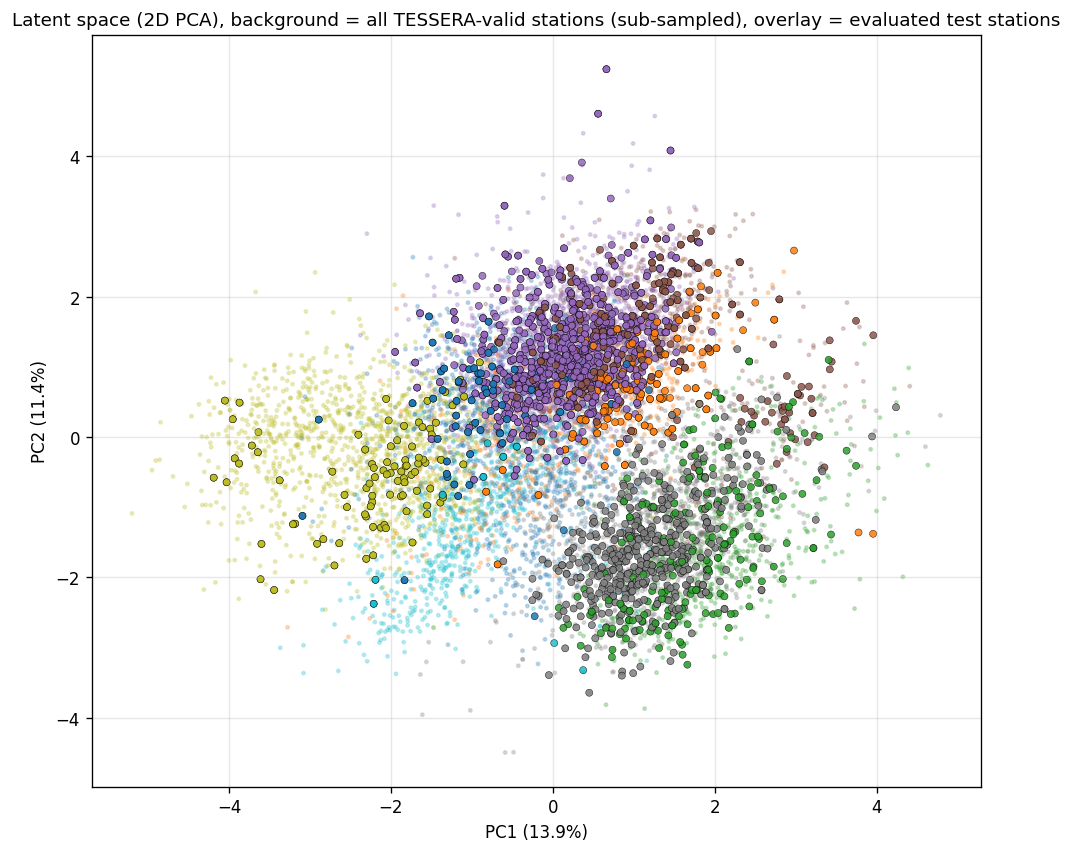

In [25]:
# 2D PCA of the 16-d latent space (computed on the full TESSERA-valid set,
# not just our test stations — so the axes are stable). Plot every test
# station projected onto the top-2 PCs and coloured by cluster. Sub-sample
# the background TESSERA-valid set for context.
# SVD on the centred matrix → top-2 directions.
Xc = latents_std - latents_std.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
explained = (S**2 / (S**2).sum())[:2]
print(f'PC1 explains {explained[0]*100:.1f}% of variance, '
      f'PC2 explains {explained[1]*100:.1f}%')
pc12 = Xc @ Vt[:2].T   # shape (N, 2)

# Background scatter: sub-sample of the global TESSERA-valid set,
# colour-coded by their k-means cluster.
rng = np.random.default_rng(0)
bg_idx = rng.choice(len(pc12), size=min(8000, len(pc12)), replace=False)
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    pc12[bg_idx, 0], pc12[bg_idx, 1],
    c=labels[bg_idx], cmap=cmap, s=4, alpha=0.25,
)
# Overlay: our evaluated test stations (smaller sample), bigger markers
# so they stand out.
test_pc12_map = pd.DataFrame({
    'station_id': valid_csv['station_id'].values,
    'pc1': pc12[:, 0], 'pc2': pc12[:, 1],
})
overlay = char_basis_local.merge(test_pc12_map, on='station_id', how='inner')
ax.scatter(
    overlay['pc1'], overlay['pc2'],
    c=overlay['cluster'].astype(int), cmap=cmap, s=18, alpha=0.85,
    edgecolor='black', linewidth=0.3,
)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('Latent space (2D PCA), background = all TESSERA-valid stations '
             '(sub-sampled), overlay = evaluated test stations')
ax.grid(True, alpha=0.3)
plt.show()


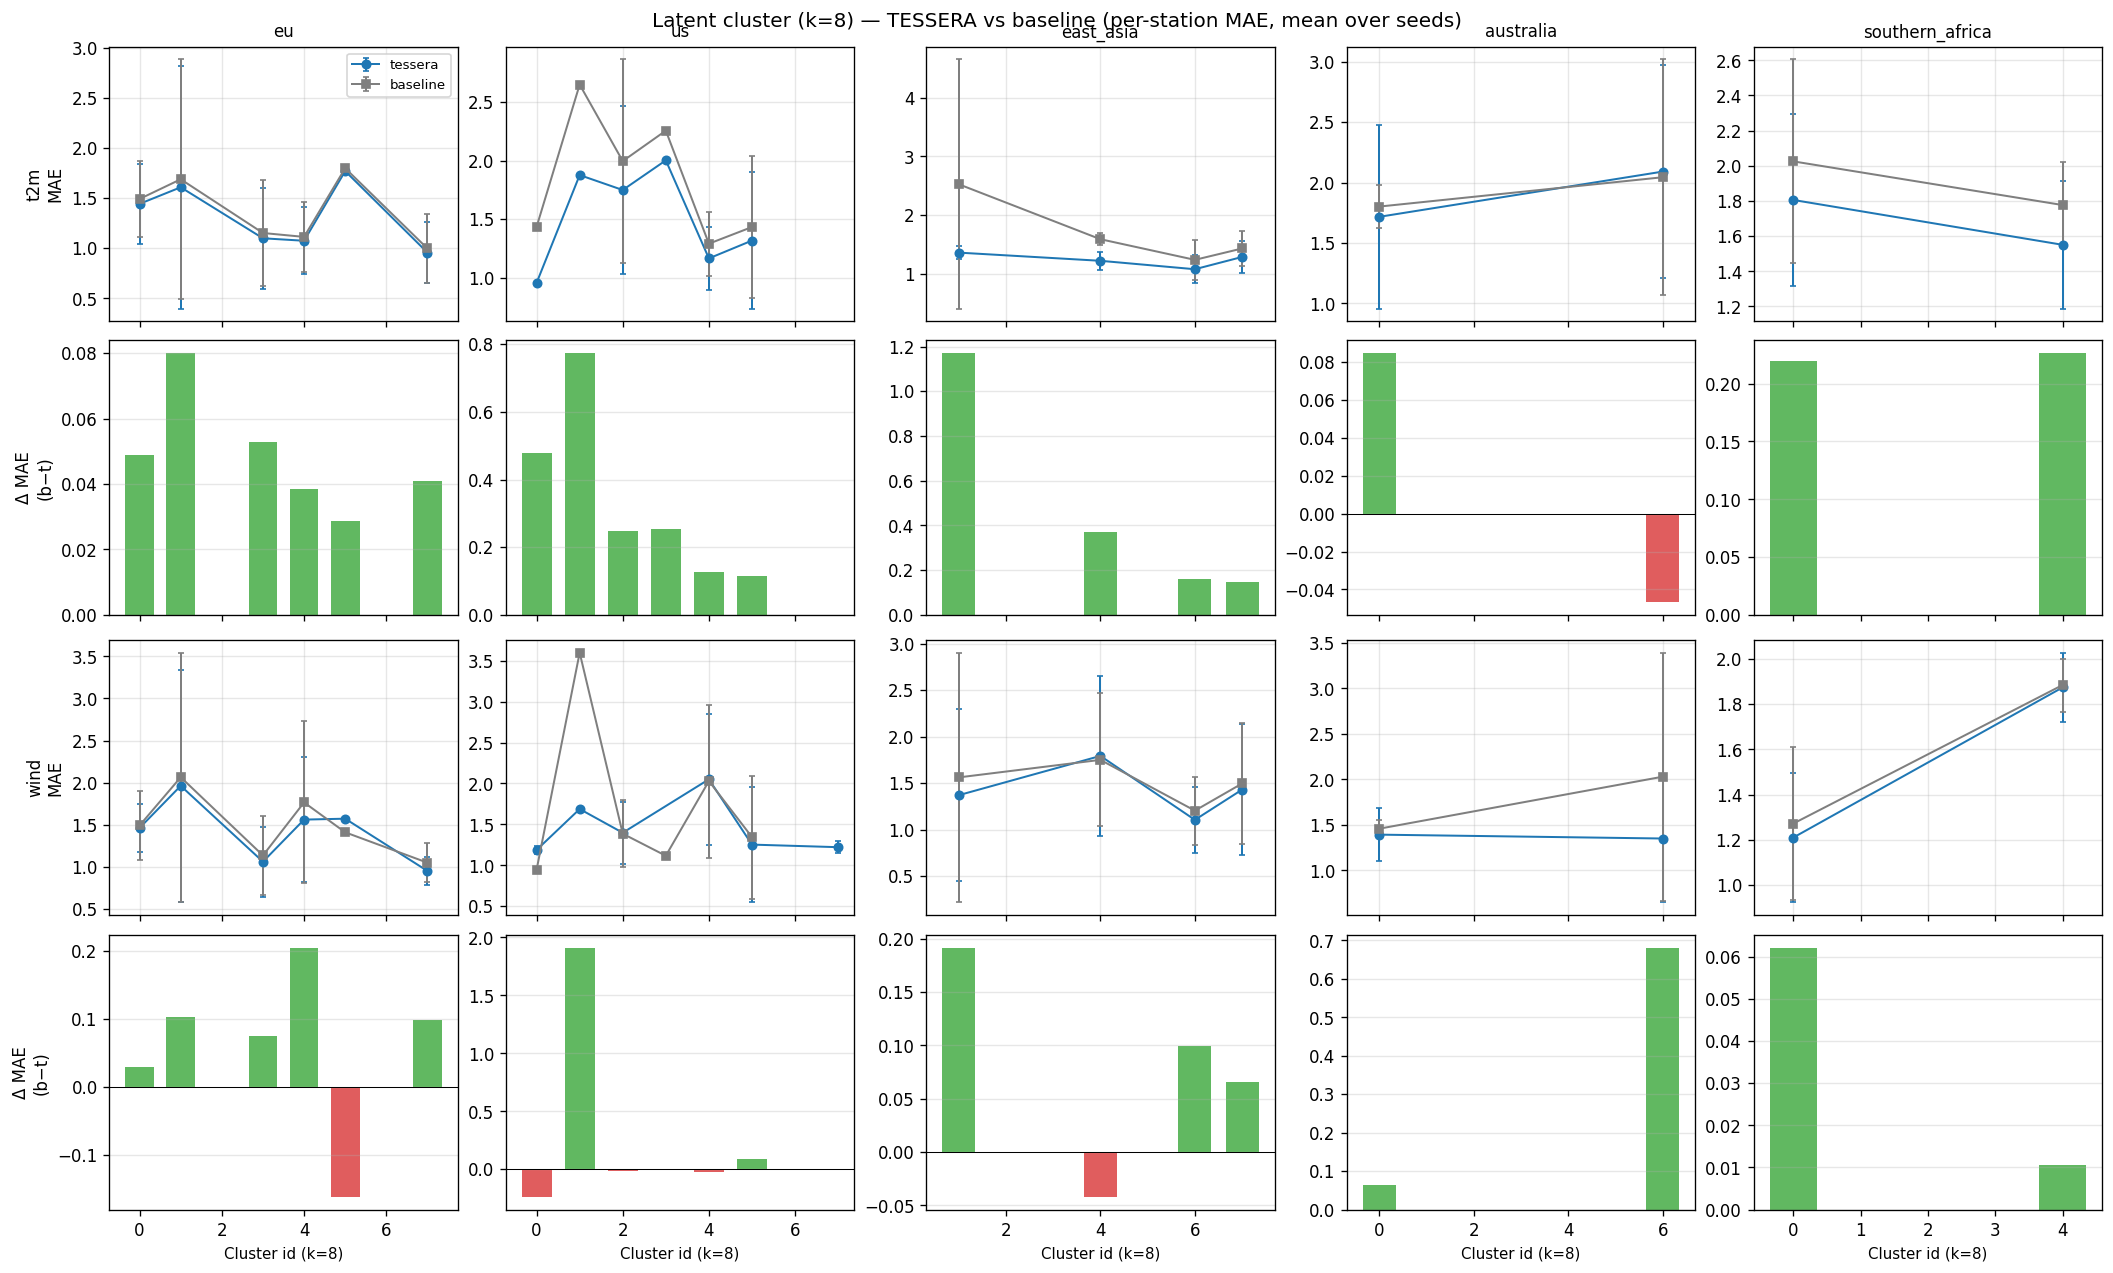

In [26]:
# Stratification: MAE-vs-cluster + per-cluster gap, in the same shape as
# the elevation / Δ-elev / density axes from the sibling notebook so the
# new plot is visually directly comparable.
ROLE_COLOUR = {'tessera': '#1f77b4', 'baseline': '#7f7f7f'}
ROLE_MARKER = {'tessera': 'o',       'baseline': 's'}


def aggregate_by_cluster(sdf: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (folder, variable, role, cluster), g in sdf.groupby(
        ['folder', 'variable', 'role', 'cluster'], dropna=True, observed=True,
    ):
        mae_vals = g['mae'].dropna()
        if mae_vals.empty:
            continue
        rows.append({
            'folder': folder, 'variable': variable, 'role': role,
            'cluster': int(cluster),
            'mae_mean': mae_vals.mean(),
            'mae_std':  mae_vals.std() if len(mae_vals) > 1 else 0.0,
            'n_stations': len(mae_vals),
        })
    return pd.DataFrame(rows)


agg = aggregate_by_cluster(station_agg)
if agg.empty:
    raise RuntimeError('Per-cluster aggregation is empty.')

folders = list(winners_df['folder'].unique())
nrows = 2 * len(VARIABLES)
ncols = len(folders)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.5 * ncols, 2.6 * nrows),
    sharex='col', squeeze=False,
)
fig.suptitle(f'Latent cluster (k={K_HEADLINE}) — TESSERA vs baseline '
             f'(per-station MAE, mean over seeds)', fontsize=12, y=1.005)
for ci, folder in enumerate(folders):
    for vi, variable in enumerate(VARIABLES):
        ax_mae = axes[vi * 2,     ci]
        ax_gap = axes[vi * 2 + 1, ci]
        sub = agg[(agg['folder'] == folder) & (agg['variable'] == variable)]
        if sub.empty:
            ax_mae.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax_mae.transAxes, color='#999999')
            ax_gap.axis('off')
            continue
        for role in ['tessera', 'baseline']:
            rr = sub[sub['role'] == role].sort_values('cluster')
            if rr.empty:
                continue
            ax_mae.errorbar(
                rr['cluster'].values, rr['mae_mean'].values,
                yerr=rr['mae_std'].fillna(0).values,
                color=ROLE_COLOUR[role], marker=ROLE_MARKER[role],
                markersize=5, capsize=2, linewidth=1.2, label=role,
            )
        ax_mae.grid(True, alpha=0.3)
        if ci == 0:
            ax_mae.set_ylabel(f'{variable}\nMAE')
        if vi == 0:
            ax_mae.set_title(folder.replace('snapshot_14y_', ''), fontsize=10)
        if vi == 0 and ci == 0:
            ax_mae.legend(fontsize=8, loc='best')
        # Gap bars.
        t = sub[sub['role'] == 'tessera'].set_index('cluster')['mae_mean']
        b = sub[sub['role'] == 'baseline'].set_index('cluster')['mae_mean']
        common = sorted(set(t.index) & set(b.index))
        if common:
            gaps = [b.loc[c] - t.loc[c] for c in common]
            cols = ['#2ca02c' if g > 0 else '#d62728' for g in gaps]
            ax_gap.bar(common, gaps, color=cols, alpha=0.75, width=0.7)
            ax_gap.axhline(0, color='black', linewidth=0.6)
            if ci == 0:
                ax_gap.set_ylabel('Δ MAE\n(b−t)')
            ax_gap.grid(True, alpha=0.3, axis='y')
        if vi == len(VARIABLES) - 1:
            ax_gap.set_xlabel(f'Cluster id (k={K_HEADLINE})', fontsize=9)
plt.show()


=== Cross-region per-cluster TESSERA gap ===
variable  cluster  n_test_stations  tessera_mae  baseline_mae     gap
     t2m        2               86       1.7482        1.9950  0.2468
     t2m        0               63       1.6627        1.8224  0.1597
     t2m        6               91       1.2079        1.3408  0.1329
     t2m        1              109       1.6010        1.7272  0.1262
     t2m        5              255       1.3182        1.4336  0.1153
     t2m        7                7       1.0965        1.1818  0.0853
     t2m        4              157       1.0931        1.1487  0.0556
     t2m        3              634       1.1003        1.1534  0.0531
    wind        6               90       1.1351        1.3053  0.1702
    wind        4              127       1.6548        1.8128  0.1581
    wind        1               79       1.9290        2.0587  0.1297
    wind        5              246       1.2539        1.3448  0.0909
    wind        7                8       1.19

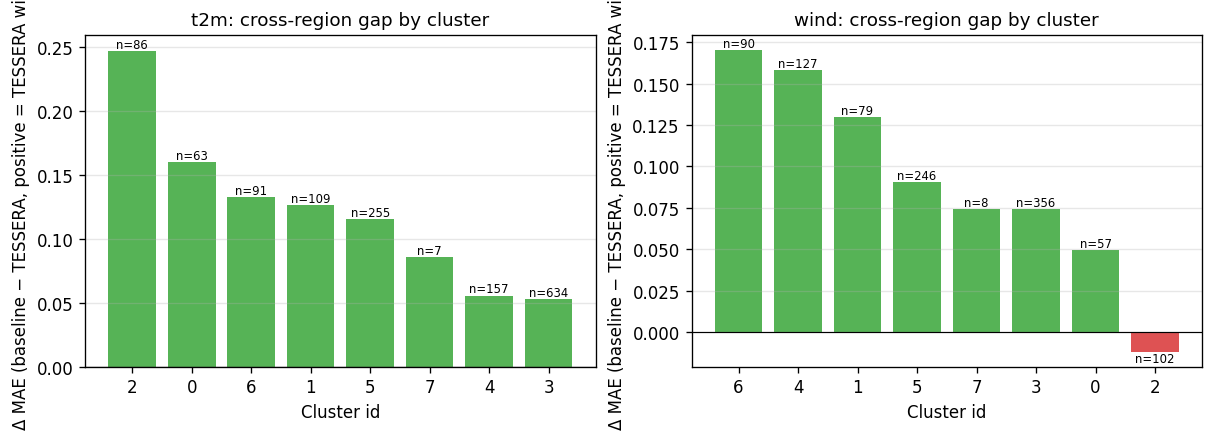

In [27]:
# Cross-region per-cluster gap: useful for spotting clusters where TESSERA
# helps regardless of which region they fall in. Averages MAE across folders
# weighted by n_stations.
def cross_region_gap_by_cluster(sdf: pd.DataFrame) -> pd.DataFrame:
    out = []
    for variable in VARIABLES:
        for cluster_id, g in sdf[sdf['variable'] == variable].groupby('cluster', dropna=True):
            # Weight MAE by n_stations per (folder, role) so a region with
            # 200 stations doesn't get the same vote as one with 5.
            wmean = (
                g.groupby('role').apply(
                    lambda r: np.average(r['mae'], weights=r['n_seeds'].clip(lower=1))
                    if not r.empty else np.nan
                )
            ).to_dict()
            t = wmean.get('tessera'); b = wmean.get('baseline')
            if t is None or b is None or np.isnan(t) or np.isnan(b):
                continue
            out.append({
                'variable':       variable,
                'cluster':        int(cluster_id),
                'n_test_stations': len(g[g['role'] == 'tessera']),
                'tessera_mae':    t,
                'baseline_mae':   b,
                'gap':            b - t,
            })
    return pd.DataFrame(out).sort_values(['variable', 'gap'], ascending=[True, False])


cross = cross_region_gap_by_cluster(station_agg)
print('=== Cross-region per-cluster TESSERA gap ===')
with pd.option_context('display.float_format', '{:.4f}'.format,
                       'display.width', 200):
    print(cross.to_string(index=False))

# Plot: per-variable, bar chart of gap by cluster (sorted descending).
fig, axes = plt.subplots(1, len(VARIABLES), figsize=(5 * len(VARIABLES), 3.5),
                          sharey=False, squeeze=False)
for ci, variable in enumerate(VARIABLES):
    ax = axes[0, ci]
    sub = cross[cross['variable'] == variable].sort_values('gap', ascending=False)
    cols = ['#2ca02c' if g > 0 else '#d62728' for g in sub['gap']]
    bars = ax.bar(sub['cluster'].astype(str), sub['gap'], color=cols, alpha=0.8)
    for bar, n in zip(bars, sub['n_test_stations']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'n={n}', ha='center', va='bottom' if bar.get_height() > 0 else 'top',
                fontsize=7)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'{variable}: cross-region gap by cluster')
    ax.set_xlabel('Cluster id')
    ax.set_ylabel('Δ MAE (baseline − TESSERA, positive = TESSERA wins)')
    ax.grid(True, alpha=0.3, axis='y')
plt.show()


=== k-sweep summary ===
 k variable  n_clusters_present  gap_mean  gap_std  gap_max  gap_min  gap_range  min_cluster_size
 4      t2m                   4    0.1340   0.0637   0.2076   0.0539     0.1537              6846
 4     wind                   4    0.1010   0.0318   0.1406   0.0632     0.0774              6846
 6      t2m                   6    0.1314   0.0670   0.2091   0.0523     0.1567              3023
 6     wind                   6    0.1192   0.0460   0.1952   0.0648     0.1304              3023
 8      t2m                   8    0.1219   0.0629   0.2468   0.0531     0.1937              2432
 8     wind                   8    0.0919   0.0598   0.1702  -0.0116     0.1818              2432
12      t2m                  12    0.1071   0.0869   0.2687  -0.0050     0.2737              1617
12     wind                  12    0.1192   0.1459   0.5478  -0.0320     0.5798              1617
16      t2m                  15    0.1146   0.1043   0.3709  -0.0050     0.3759               

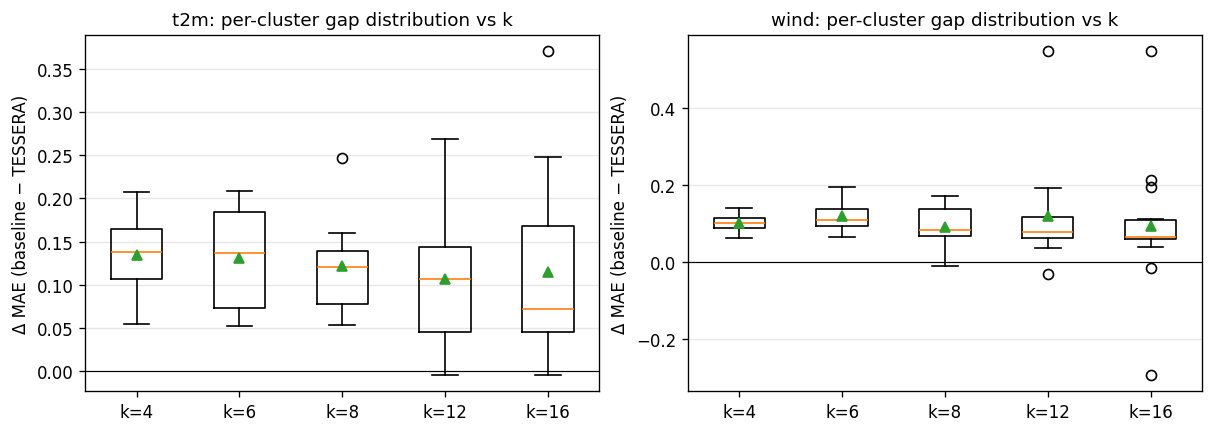

In [28]:
# k-sweep sanity check: is the headline "some clusters benefit more than
# others" stable across k? For each k in K_SWEEP, refit k-means, assign
# labels, compute per-cluster cross-region gap, and report the spread
# (std and IQR) of per-cluster gaps.
#
# Larger gap spread → more discriminative clustering. If the spread is
# similar across k, the structure is real; if only one k shows a large
# spread, we're seeing a k-artefact.
def fit_and_cluster_gaps(k: int) -> dict:
    np.random.seed(KMEANS_SEED)
    centroids_k, labels_k = kmeans2(
        latents_std, k=k, seed=KMEANS_SEED, minit='++',
        iter=200, missing='raise',
    )
    lookup_k = pd.DataFrame({
        'station_id': valid_csv['station_id'].values,
        'cluster_k': labels_k,
    })
    sa = station_agg.drop(columns=['cluster']).merge(lookup_k, on='station_id', how='left')
    sa['cluster_k'] = sa['cluster_k'].astype('Int64')
    sa = sa.dropna(subset=['cluster_k'])
    sa = sa.rename(columns={'cluster_k': 'cluster'})
    cross_k = cross_region_gap_by_cluster(sa)
    return {'k': k, 'cross': cross_k, 'sizes': pd.Series(labels_k).value_counts().sort_index()}


sweep_results = [fit_and_cluster_gaps(k) for k in K_SWEEP]

# Summary table: per (k, variable) report mean gap, std of gaps across
# clusters, and the gap of the best / worst cluster.
sum_rows = []
for r in sweep_results:
    for variable in VARIABLES:
        sub = r['cross'][r['cross']['variable'] == variable]
        if sub.empty:
            continue
        sum_rows.append({
            'k':            r['k'],
            'variable':     variable,
            'n_clusters_present': sub['cluster'].nunique(),
            'gap_mean':     sub['gap'].mean(),
            'gap_std':      sub['gap'].std(),
            'gap_max':      sub['gap'].max(),
            'gap_min':      sub['gap'].min(),
            'gap_range':    sub['gap'].max() - sub['gap'].min(),
            'min_cluster_size': int(r['sizes'].min()),
        })
sum_df = pd.DataFrame(sum_rows)
print('=== k-sweep summary ===')
with pd.option_context('display.float_format', '{:.4f}'.format,
                       'display.width', 200):
    print(sum_df.to_string(index=False))

# Plot: per-variable, gap distribution (box) across clusters as a function of k.
fig, axes = plt.subplots(1, len(VARIABLES), figsize=(5 * len(VARIABLES), 3.5),
                          sharey=False, squeeze=False)
for ci, variable in enumerate(VARIABLES):
    ax = axes[0, ci]
    data = []
    labels_k = []
    for r in sweep_results:
        sub = r['cross'][r['cross']['variable'] == variable]['gap'].values
        if len(sub) == 0:
            continue
        data.append(sub)
        labels_k.append(f'k={r["k"]}')
    bp = ax.boxplot(data, tick_labels=labels_k, showmeans=True, widths=0.5)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'{variable}: per-cluster gap distribution vs k')
    ax.set_ylabel('Δ MAE (baseline − TESSERA)')
    ax.grid(True, alpha=0.3, axis='y')
plt.show()


## Reading the plots

### Geographic map + cluster characterisation
Look for clusters that **span multiple regions** vs **concentrate in one**.
A cluster that has 40+ stations across EU, US, and east_asia is a *globally
recurring landscape regime*; one that's 95% east_asia is something
region-specific. The characterisation table's `lat_std` / `lon_std` /
`elev_std` quantify this.

### 2D PCA
If the 8 clusters look like 8 well-separated blobs in 2D, the latent space
has obvious low-dim structure and the clusters are likely meaningful.
If they overlap heavily, the structure is high-dimensional — the clusters
are still real, but the 2D projection is just a poor view of them.
Either way, the stratification plot is the answer; the PCA is just a
visual diagnostic.

### Stratification plot (cluster as axis)
Same as before: green bars = TESSERA wins, red = baseline wins.
The **headline claim** to look for: do some clusters show consistently
larger green bars across regions? If cluster 3's gap is large in EU AND US
AND southern_africa, that's evidence the gap correlates with a
location-independent landscape property.

### Cross-region per-cluster gap (sorted)
This is the most paper-ready view: rank clusters by their cross-region gap
and ask "what makes the top-ranked cluster distinctive?" — using the
characterisation table from earlier to put a name on it.

### k-sweep
If `gap_range` and `gap_std` stay roughly comparable across k=4 … 16, the
clustering is finding a real structure (not a k-artefact). If `gap_range`
collapses at small k (everything averaged together) but is large at k=8 and
beyond, that's evidence the meaningful regime count is ≥ 6 or so.

### Next moves if v1 looks promising

1. **Hand-label the top-gap clusters** using the characterisation table:
   centroid in (lat, lon) → look up CORINE / WorldCover / OSM and see
   what the dominant land cover is.
2. **v2 — patch-level clustering.** Cluster the raw 64×64 patch
   embeddings and check that the cluster structure agrees with the
   latent-based one. Disagreement would suggest the VAE compressed away
   discriminative info.
3. **Tie back to literature.** If clusters split clean by, say, surface
   roughness or vegetation, cross-reference with downscaling literature
   on the roles of these variables (Seneviratne et al. on land-atm
   coupling; the various wind-roughness corrections; etc.).
